## Imports

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from collections import OrderedDict
import matplotlib.pyplot as plt 
from sklearn.metrics import roc_curve, auc, precision_recall_curve, confusion_matrix
import seaborn as sns

import time 
import os

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from torchvision.models import resnet50, ResNet50_Weights, vit_b_32, ViT_B_32_Weights, convnext_base, ConvNeXt_Base_Weights
from torcheval.metrics import BinaryAUROC, BinaryAUPRC, BinaryAccuracy
from torch.nn.functional import softmax

from deepfake_utils.datasets import DeepFakeDataset
from deepfake_utils.models import MyModel
from deepfake_utils.train import validate_epoch

Extension horovod.torch has not been built: /anaconda/envs/azureml_py38_PT_TF/lib/python3.10/site-packages/horovod/torch/mpi_lib_v2.cpython-310-x86_64-linux-gnu.so not found
If this is not expected, reinstall Horovod with HOROVOD_WITH_PYTORCH=1 to debug the build error.
Warning! MPI libs are missing, but python applications are still available.


In [2]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

In [3]:
experiment_results = pd.read_csv("experiment_results/experiment_results_final_benchmark_07222025.csv")
experiment_results.head()

,Unnamed: 0,experiment_id,model,freeze_layers,dropout_rate,l2-penalty,optimizer,epochs,learning_rate,lr_scheduler_type,...,val_pr_auc_history,val_acc_history,train_loss,train_roc_auc,train_pr_auc,train_acc,val_loss,val_roc_auc,val_pr_auc,val_acc
0,0,1,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00001,StepLR,...,"[0.6192221641540527, 0.596264123916626, 0.6191...","[0.5897436141967773, 0.5555555820465088, 0.538...",0.767728,0.499430,0.613818,0.494747,0.709287,0.532149,0.619222,0.589744
1,1,2,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00001,CosineAnnealingWarmRestarts,...,"[0.5789679288864136, 0.6239730715751648, 0.643...","[0.5897436141967773, 0.5641025900840759, 0.564...",0.679981,0.558618,0.643018,0.596944,0.676083,0.544703,0.678314,0.632479
2,2,3,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00010,StepLR,...,"[0.7245486974716187, 0.5707476735115051, 0.654...","[0.5299145579338074, 0.5897436141967773, 0.521...",0.755958,0.552598,0.656636,0.572111,0.752767,0.434783,0.570748,0.589744
3,3,4,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00010,CosineAnnealingWarmRestarts,...,"[0.6523077487945557, 0.6402071118354797, 0.668...","[0.5128205418586731, 0.5470085740089417, 0.538...",0.685774,0.549622,0.652212,0.577841,0.706475,0.426516,0.533404,0.598291
4,4,5,ConvNeXt-base-scratch,False,0.2,0.0,Adam,50,0.00100,StepLR,...,"[0.6186792850494385, 0.646340012550354, 0.6644...","[0.6153846383094788, 0.5384615659713745, 0.547...",2.059432,0.488919,0.602562,0.510029,0.741109,0.551439,0.618679,0.615385


In [4]:
# focus on evaluating the best model settings for each family (i.e. 1 for ResNet, 1 for ViT, 1 for ConvNeXt)
# "best" is open to redefining a bit later depending on model complexity etc. but maybe just go with highest ROC AUC on validation data for now
experiment_results.sort_values(by=['val_acc', 'val_roc_auc'], ascending = False).groupby("model").first()[['experiment_id', 'val_roc_auc', 'val_pr_auc', 'val_acc', 'val_loss', 'train_roc_auc', 'train_pr_auc', 'train_acc', 'train_loss']]
# experiment_results.sort_values(by='val_roc_auc', ascending = False).groupby("model").head(3)

,experiment_id,val_roc_auc,val_pr_auc,val_acc,val_loss,train_roc_auc,train_pr_auc,train_acc,train_loss
model,,,,,,,,,
ConvNeXt-base-pretrained,46,0.861604,0.919166,0.803419,0.854010,0.999996,0.999998,0.999045,0.010171
ConvNeXt-base-pretrained-clip,2,0.902327,0.941156,0.846154,0.490511,0.992791,0.995570,0.962751,0.113731
ConvNeXt-base-scratch,56,0.607165,0.672875,0.658120,0.664588,0.566098,0.660875,0.594078,0.720223
ResNet-50-pretrained,64,0.871555,0.928704,0.811966,0.536489,0.999563,0.999722,0.986628,0.058730
ResNet-50-pretrained-clip,51,0.861911,0.910722,0.811966,0.738837,0.999755,0.999850,0.995224,0.027657
ResNet-50-scratch,17,0.812921,0.852441,0.794872,0.525099,0.868704,0.907902,0.796562,0.436773
ViT-b32-pretrained,38,0.862829,0.922369,0.820513,0.595384,0.997538,0.998508,0.981853,0.083455
ViT-b32-pretrained-clip,50,0.876607,0.933870,0.837607,0.609752,0.994571,0.996331,0.974212,0.080009
ViT-b32-scratch,62,0.639927,0.689035,0.692308,0.640606,0.598751,0.696440,0.607450,0.694077


## Evaluate Test Performance (ROC curves, precision-recall curves, tables etc.)

In [5]:
image_dir_path = 'Deepfake-Eval-2024/image-data'

In [6]:
train_data = DeepFakeDataset("image-metadata-train.csv", image_dir_path, model_type = 'ConvNeXt-CLIP', is_train = False)

# test_data = DeepFakeDataset("image-metadata-test.csv", image_dir_path, model_type = 'ConvNeXt-CLIP',  is_train = False)
# test_data_loader = DataLoader(test_data, batch_size = 32, shuffle = False)
# print(f"Successfully loaded {len(test_data)} samples for testing.")
# print(f"Test data will be loaded in batches of {test_data_loader.batch_size}.")

In [7]:
# maybe copy code from validate_epoch or create new utility function that returns the actual per-sample predictions so that we can plot ROC curves etc.
# this particular commit probably has tensors needed to do that
# https://github.com/Deepfake-Detection-KKO/deepfake-detection/blob/59df359e6d76043bd40df4a3fa0571ce67f79861/deepfake_utils/train.py

In [8]:
# Custom validate_epoch function to accumulate and return all labels and probabilites for ROC-AUC and PR-AUC plots. 
def print_(message, log = True):
    if log:
        print(message)

def validate_epoch(dataloader, model, loss_fn, device, verbose = True, log_interval=5, return_preds_labels=False):
    model.eval() 
    val_loss = 0
    acc_metric = BinaryAccuracy(device=device)
    auroc_metric = BinaryAUROC(device=device)
    auprc_metric = BinaryAUPRC(device=device)

    all_labels = []
    all_probabilities = []
    
    loss_fn.reduction = 'sum' 
    
    with torch.no_grad():
        for batch, (X, y) in enumerate(dataloader):
            X = X.to(device)
            y = y.to(device)

            pred = model(X)
            val_loss += loss_fn(pred, y).item()
            
            pred_prob = softmax(pred, dim = 1)
            
            if return_preds_labels:
                all_labels.extend(y.cpu().numpy())
                all_probabilities.extend(pred_prob[:, 1].cpu().numpy())

            acc_metric.update(pred_prob[:, 1], y)
            auroc_metric.update(pred_prob[:, 1], y)
            auprc_metric.update(pred_prob[:, 1], y)
        
            if (batch + 1) % log_interval == 0 or (batch + 1) == len(dataloader):
                current = (batch + 1) * dataloader.batch_size
                print_(f"\tEvaluation Progress: \t[{current:>5d}/{len(dataloader.dataset):>5d}]", verbose)

    val_loss /= len(dataloader.dataset)
    val_acc = acc_metric.compute()
    
    if device.type == 'mps':
        results = (val_loss, float('nan'), float('nan'), val_acc.item())
    else:
        val_auroc = auroc_metric.compute()
        val_auprc = auprc_metric.compute()
        results = (val_loss, val_auroc.item(), val_auprc.item(), val_acc.item())

    if return_preds_labels:
        return (*results, np.array(all_probabilities), np.array(all_labels))
    else:
        return results

In [9]:
# Dictionary to store results for plotting 
model_results = {} 

# Adjust these paths to your actual saved model weights. Currentlt, it is hardcoded
models_to_test = {
    "ResNet-50-pretrained-clip": 'model_weights/experiment_weights_07212025_resnet_clip_51.pth',
    "ViT-b32-pretrained-clip": 'model_weights/experiment_weights_07212025_vit_clip_50.pth',
    "ConvNeXt-base-pretrained-clip": 'model_weights/experiment_weights_07212025_convnext_clip_2.pth',
}
preprocessors = {
    "ResNet-50-pretrained-clip": 'ResNet-CLIP',
    "ViT-b32-pretrained-clip": 'ViT-CLIP',
    "ConvNeXt-base-pretrained-clip": 'ConvNeXt-CLIP',
}

In [10]:
# Loop through each model to load, evaluate, and collect data for the ROC-AUC and PR-AUC plots
for model_name, weights_path in models_to_test.items():
    print(f"\n Evaluating {model_name}")

    # Initialize the model architecture
    current_model = MyModel(model_name, device, num_classes=2, freeze_layers=True)
    # Load the specific model's weights
    try:
        current_model_weights = torch.load(weights_path, weights_only=True, map_location=device)
        current_model_weights_cleaned = type(current_model_weights)([
            (k.replace("_orig_mod.", ""), v) for k, v in current_model_weights.items()
        ])
        current_model.load_state_dict(current_model_weights_cleaned)
        print(f"Loaded weights for {model_name} from {weights_path}.")
    except FileNotFoundError:
        print(f"Error: {weights_path} not found. Skipping {model_name}.")
        continue
    except Exception as e:
        print(f"Error loading state_dict for {model_name} from {weights_path}: {e}. Skipping.")
        continue

    test_data = DeepFakeDataset("image-metadata-test.csv", image_dir_path, model_type = preprocessors[model_name],  is_train = False)
    print(f"Loaded test data with {len(test_data)} samples and {preprocessors[model_name]} preprocessor")
    test_data_loader = DataLoader(test_data, batch_size = 32, shuffle = False)
    current_model.to(device) 
    # Get predictions and labels from the test set using validate_epoch
    # Pass return_preds_labels=True to get per-sample data
    # The return type depends on whether device.type == 'mps'
    results = validate_epoch(
        dataloader=test_data_loader, 
        model=current_model,
        loss_fn=nn.CrossEntropyLoss(), 
        device=device,
        verbose=True,
        return_preds_labels=True # Crucial for getting data for ROC curve
    )

    # Unpack results based on the return_preds_labels flag and MPS check
    if device.type == 'mps':
        test_loss, _, _, test_accuracy, all_probs, all_labels = results
        test_roc_auc_for_display = float('nan') # Explicitly set NaN for print
    else:
        test_loss, test_roc_auc_for_display, test_pr_auc_for_display, test_accuracy, all_probs, all_labels = results

    print(f"\n--- {model_name} Test Results ---")
    print(f"Test Loss: {test_loss:.4f}")
    # Handle printing ROC AUC/PR AUC based on MPS
    if device.type == 'mps':
        print(f"Test ROC AUC: {test_roc_auc_for_display:.4f} (Not computed on MPS)")
        print(f"Test PR AUC: {test_pr_auc_for_display:.4f} (Not computed on MPS)")
    else:
        print(f"Test ROC AUC: {test_roc_auc_for_display:.4f}")
        print(f"Test PR AUC: {test_pr_auc_for_display:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Calculate ROC curve from collected probabilities and labels
    fpr, tpr, _ = roc_curve(all_labels, all_probs)
    calculated_roc_auc = auc(fpr, tpr)
    
    # Calculate Precision-Recall curve
    precision, recall, _ = precision_recall_curve(all_labels, all_probs)
    calculated_pr_auc = auc(recall, precision) 
    FIGURE_WIDTH = 6.875 
    FIGURE_HEIGHT = FIGURE_WIDTH * 0.75 
    FONTSIZE_TITLE = 16
    FONTSIZE_LABELS = 16
    FONTSIZE_TICKS = 12
    FONTSIZE_LEGEND = 15 
    FONTSIZE_TEXT_ON_BARS = 10 
    DPI = 300

    # Add confusion matrix
    predicted_classes = (all_probs > 0.5).astype(int)

    # Generate the confusion matrix
    cm = confusion_matrix(all_labels, predicted_classes)
    print(f"\nConfusion Matrix for {model_name}:\n", cm)

    # Plot and save the confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'], # Assuming 0 is 'Real', 1 is 'Fake'
                yticklabels=['Real', 'Fake'])
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title(f'Confusion Matrix: {model_name}')
    plt.tight_layout()

    OUTPUT_PLOTS_DIR ="performance_plots"
    os.makedirs(OUTPUT_PLOTS_DIR, exist_ok =True)
    cm_plot_path = os.path.join(OUTPUT_PLOTS_DIR, f'{model_name}_confusion_matrix.png')
    plt.savefig(cm_plot_path, dpi=DPI) # Use your defined DPI

    plt.close() 
    print(f"Saved Confusion Matrix plot to: {cm_plot_path}")

    # Store all results in model_results dictionary 
    model_results[model_name] = {
        'test_loss': test_loss,
        'test_roc_auc': test_roc_auc_for_display, # Use the displayed value (might be NaN for MPS)
        'test_pr_auc': test_pr_auc_for_display,   # Use the displayed value (might be NaN for MPS)
        'test_accuracy': test_accuracy,
        'fpr': fpr,
        'tpr': tpr,
        'roc_auc': calculated_roc_auc, # AUC calculated from fpr/tpr for plot
        'precision': precision,
        'recall': recall,
        'pr_auc': calculated_pr_auc,   # AUC calculated from precision/recall for plot
        'confusion_matrix': cm.tolist()
    }


 Evaluating ResNet-50-pretrained-clip
Loaded weights for ResNet-50-pretrained-clip from model_weights/experiment_weights_07212025_resnet_clip_51.pth.
Loaded test data with 786 samples and ResNet-CLIP preprocessor
	Evaluation Progress: 	[  160/  786]
	Evaluation Progress: 	[  320/  786]
	Evaluation Progress: 	[  480/  786]
	Evaluation Progress: 	[  640/  786]
	Evaluation Progress: 	[  800/  786]

--- ResNet-50-pretrained-clip Test Results ---
Test Loss: 0.7761
Test ROC AUC: 0.8647
Test PR AUC: 0.9140
Test Accuracy: 0.7888

Confusion Matrix for ResNet-50-pretrained-clip:
 [[206  99]
 [ 67 414]]
Saved Confusion Matrix plot to: performance_plots/ResNet-50-pretrained-clip_confusion_matrix.png

 Evaluating ViT-b32-pretrained-clip
Loaded weights for ViT-b32-pretrained-clip from model_weights/experiment_weights_07212025_vit_clip_50.pth.
Loaded test data with 786 samples and ViT-CLIP preprocessor
	Evaluation Progress: 	[  160/  786]
	Evaluation Progress: 	[  320/  786]
	Evaluation Progress: 	[

/anaconda/envs/azureml_py38_PT_TF/lib/python3.10/site-packages/open_clip/factory.py:388: UserWarning: These pretrained weights were trained with QuickGELU activation but the model config does not have that enabled. Consider using a model config with a "-quickgelu" suffix or enable with a flag.
  warnings.warn(


In [11]:
plt.rcParams['font.size'] = 8

/tmp/ipykernel_23879/3481914402.py:24: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "k:" (-> linestyle=':'). The keyword argument will take precedence.
  ax2.plot([0, 1], [positive_class_proportion, positive_class_proportion], 'k:', linestyle='--', label=f'No Skill (PR AUC = {positive_class_proportion:.2f})')


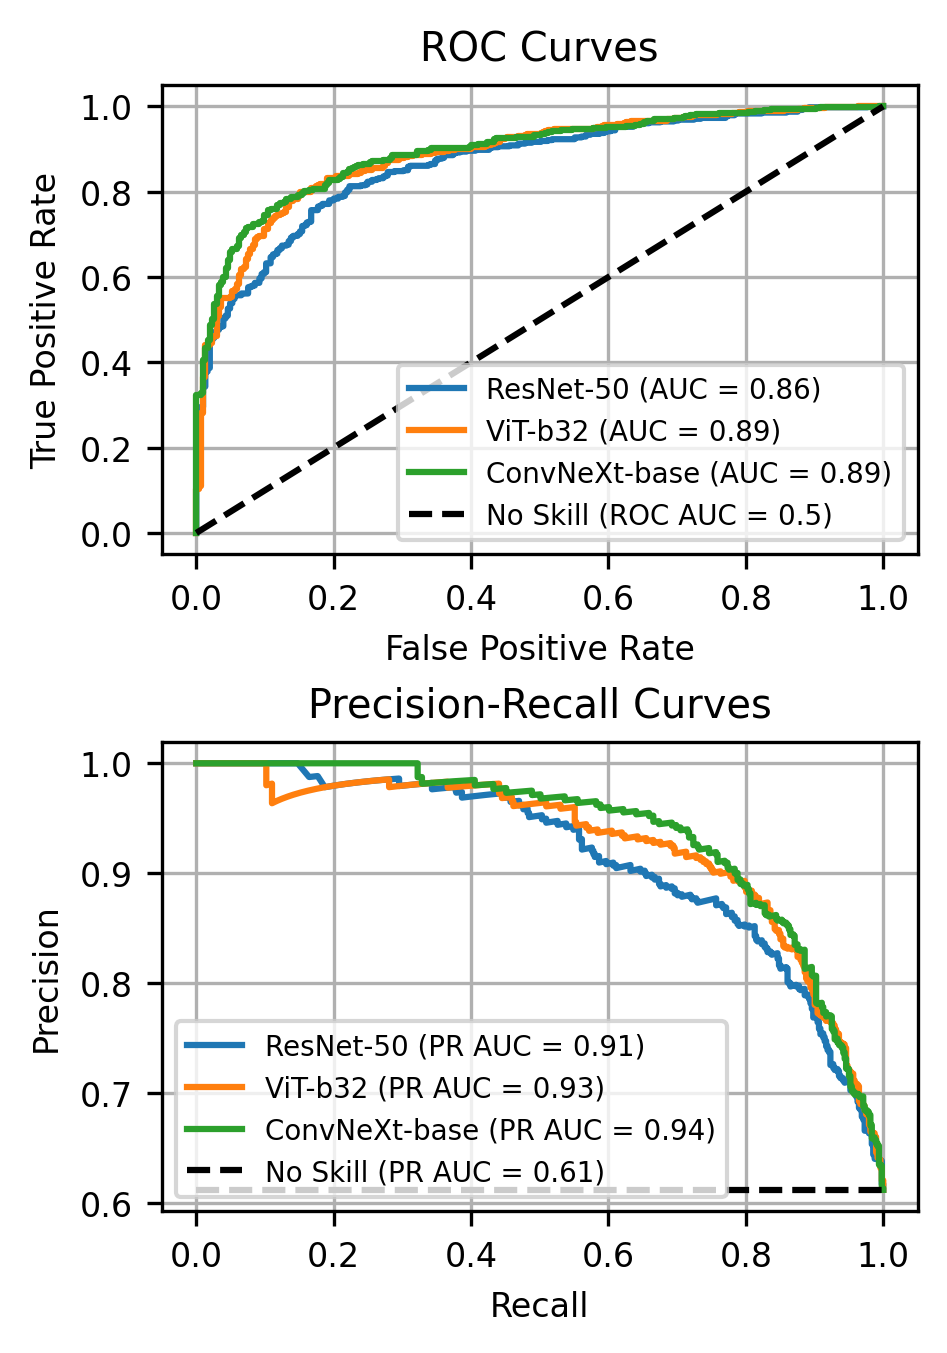

In [12]:

# Plot the ROC Curves
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(3.25, 2*3.25*0.75), dpi = 300)
plt.subplots_adjust(wspace=0.5, hspace=0.4)

for col, (model_name, results) in enumerate(model_results.items()):
    # ax1.plot(results['fpr'], results['tpr'], color = f"C{col}")
    ax1.plot(results['fpr'], results['tpr'], label=f'{"-".join(model_name.split("-")[:2])} (AUC = {results["roc_auc"]:.2f})')

ax1.plot([0, 1], [0, 1], 'k--', label=f'No Skill (ROC AUC = 0.5)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curves')
ax1.legend(loc='lower right', fontsize = 'small') # Increased legend fontsize
ax1.grid(True)


for col, (model_name, results) in enumerate(model_results.items()):
    ax2.plot(results['recall'], results['precision'], label=f'{"-".join(model_name.split("-")[:2])} (PR AUC = {results["pr_auc"]:.2f})')

# Baseline for PR curve: For a random classifier, PR AUC is the proportion of positive samples
# Calculate the positive class proportion from any set of labels (they should be the same across models)
if all_labels is not None: 
    positive_class_proportion = np.sum(all_labels) / len(all_labels)
    ax2.plot([0, 1], [positive_class_proportion, positive_class_proportion], 'k:', linestyle='--', label=f'No Skill (PR AUC = {positive_class_proportion:.2f})')
    # ax2.plot([0, 1], [positive_class_proportion, positive_class_proportion], 'k:', linestyle='--', label=f'No Skill')
else:
    # Fallback if all_labels wasn't set, e.g., due to an error earlier
    print("Warning: Could not determine positive class proportion for PR AUC baseline.")

# ax2.set_ylim([0,1])
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curves')
ax2.legend(loc='lower left', fontsize = 'small') # Increased legend fontsize
ax2.grid(True)

plt.savefig('performance_plots/roc_pr_curves.png', bbox_inches='tight', dpi = DPI)

In [13]:
# Inference metrics will need to be run separately in PACE
# schedulq run_inference_speed_test.sch 
# It will output results in slurm_outputs folder as inference_speed_test_<...>.out
# copy and paste that manually in the output

# below is the inference speed test output from 07-22-2025 19:50 cdt
"""
\begin{table}
\caption{Average Inference Time per Model (Batch Size=1)}
\label{tab:inference_time_performance}
\begin{tabular}{l|c}
\toprule
Model & Inference Time (ms) \\
\midrule
ViT-b32-pretrained-clip & \textbf{15.995 $\pm$ 0.176} \\
ConvNeXt-base-pretrained-clip & 44.247 $\pm$ 1.072 \\
ResNet-50-pretrained-clip & 21.959 $\pm$ 0.092 \\
\bottomrule
\end{tabular}
\end{table}
"""

'\n\x08egin{table}\n\\caption{Average Inference Time per Model (Batch Size=1)}\n\\label{tab:inference_time_performance}\n\x08egin{tabular}{l|c}\n\toprule\nModel & Inference Time (ms) \\\n\\midrule\nViT-b32-pretrained-clip & \textbf{15.995 $\\pm$ 0.176} \\\nConvNeXt-base-pretrained-clip & 44.247 $\\pm$ 1.072 \\\nResNet-50-pretrained-clip & 21.959 $\\pm$ 0.092 \\\n\x08ottomrule\n\\end{tabular}\n\\end{table}\n'

In [14]:
# Prepare data for DataFrame
table_data = []
for model_name, results in model_results.items():
    table_data.append({
        "Model": model_name,
        # "Test Loss": results['test_loss'],
        # "Test ROC AUC": results['test_roc_auc'],
        # "Test PR AUC": results['test_pr_auc'],
        "\\multicolumn{2}{c}{\\centering Test Accuracy}": results['test_accuracy'],
        # "Inference Time (ms)": f"{results['avg_inference_ms']:.3f} $\\pm$ {results['std_inference_ms']:.3f}"
    })

df_table = pd.DataFrame(table_data)

In [15]:
df_table

,Model,\multicolumn{2}{c}{\centering Test Accuracy}
0,ResNet-50-pretrained-clip,0.788804
1,ViT-b32-pretrained-clip,0.805344
2,ConvNeXt-base-pretrained-clip,0.812977


In [18]:
pos = 0
neg = 0
for rec in train_data:
    if rec[1] == 1:
        pos +=1
    else:
        neg += 1
print((pos/(pos+neg)))

In [ ]:
pos, neg

In [ ]:
open_source_rec = pd.DataFrame({'Model': 'Leading Open-Source Model', '\\multicolumn{2}{c}{\\centering Test Accuracy}': 0.69}, index = [3])
commercial_rec = pd.DataFrame({'Model': 'Leading Commercial Model', '\\multicolumn{2}{c}{\\centering Test Accuracy}': 0.82}, index = [3])
no_skill_rec = pd.DataFrame({'Model': 'No Skill Classifier', '\\multicolumn{2}{c}{\\centering Test Accuracy}': (pos/(pos+neg))}, index = [3])
df_table = pd.concat((df_table, open_source_rec, commercial_rec, no_skill_rec), axis = 0)

In [ ]:
df_table

In [ ]:
# source:https://github.com/mlfoundations/open_clip/blob/main/docs/model_profile.csv
# need to ensure data is in correct order
df_table['Model'] = ['ResNet-50', 'ViT-b32', 'ConvNeXt-base', 'Leading Open-Source Model', 'Leading Commercial Model', 'No Skill Classifier']
col = df_table['\\multicolumn{2}{c}{\\centering Test Accuracy}'].tolist()
df_table['\\multicolumn{2}{c}{\\centering Test Accuracy}'] = [f"{round(i,2)} & \\tablebar{{{round(i / max(col), 2)}}}{{teal}}" if i else '\\multicolumn{2}{c}{\\centering -- }' for i in col]
col = [38.32, 87.85, 88.09, 0, 0, 0]
df_table['\\multicolumn{2}{c}{\\centering Parameters}'] = [f"{round(i,2)} & \\tablebar{{{round(i / max(col), 2)}}}{{purple}}" if i else '\\multicolumn{2}{c}{\\centering -- }' for i in col]
col = [12.22, 8.82, 30.71, 0, 0, 0]
df_table['\\multicolumn{2}{c}{\\centering GFLOPS}'] = [f"{round(i,2)} & \\tablebar{{{round(i / max(col), 2)}}}{{violet}}" if i else '\\multicolumn{2}{c}{\\centering -- }' for i in col]
col = [21.96, 16.00, 44.25, 0, 0, 0]
df_table['\\multicolumn{2}{c}{\\centering Inference Speed (ms)}'] = [f"{round(i,2)} & \\tablebar{{{round(i / max(col), 2)}}}{{violet}}"  if i else '\\multicolumn{2}{c}{\\centering -- }' for i in col]

In [ ]:
df_table

In [ ]:
# Generate LaTeX Table with Inference Speed 

# # Prepare data for DataFrame
# table_data = []
# for model_name, results in model_results.items():
#     table_data.append({
#         "Model": model_name,
#         # "Test Loss": results['test_loss'],
#         # "Test ROC AUC": results['test_roc_auc'],
#         # "Test PR AUC": results['test_pr_auc'],
#         "Test Accuracy": results['test_accuracy'],
#         # "Inference Time (ms)": f"{results['avg_inference_ms']:.3f} $\\pm$ {results['std_inference_ms']:.3f}"
#     })

# df_table = pd.DataFrame(table_data)

# Find the best performing model for each metric and bold it

# For Loss and Inference Time, lower is better. For AUCs and Accuracy, higher is better.
# bold_cols_numeric = ["\\multicolumn{2}{c}{\\centering Test Accuracy}"]
# # bold_col_inference_time = "Inference Time (ms)"

# def bold_best_numeric(series, metric_name):
#     numeric_series = pd.to_numeric(series, errors='coerce')
#     if "Loss" in metric_name:
#         best_val = numeric_series.min()
#     else:
#         best_val = numeric_series.max()

# def bold_best_numeric(series, metric_name):
#     numeric_series = pd.to_numeric(series, errors='coerce')
#     if "Loss" in metric_name:
#         best_val = numeric_series.min()
#     else:
#         best_val = numeric_series.max()
#     return [f"\\textbf{{{x:.4f}}}" if x == best_val and not pd.isna(x) else (f"{x:.4f}" if not pd.isna(x) else "N/A") for x in numeric_series]

# def bold_best_inference_time(series):
#     avg_times = [float(s.split(' ')[0]) if '$\\pm$' in s else float('inf') for s in series]
#     best_val_idx = np.argmin(avg_times)
#     return [f"\\textbf{{{s}}}" if i == best_val_idx else s for i, s in enumerate(series)]

# for col in bold_cols_numeric:
#     # Ensure values are numeric before passing to bold_best_numeric
#     # If they are already floats/nans from validate_epoch, this is fine
#     df_table[col] = bold_best_numeric(df_table[col], col)

# # # Apply bolding for inference time
# # df_table[bold_col_inference_time] = bold_best_inference_time(df_table[bold_col_inference_time])

# Generate LaTeX table
latex_table = df_table.to_latex(
    index=False,
    escape=False, # Important to keep LaTeX commands like \textbf and \pm
    column_format="r||cl|cl|cl|cl", # Added one more 'c' for Inference Time
    caption="Test Accuracy and Computational Performance",
    label="tab:test_accuracy_computational_performance"
)

print("\n\n--- LaTeX Table with All Metrics ---")
print(latex_table)